### 1. **定积分的计算**

例 16.4 求二重积分 $I = \iint\limits_{x^2 + y^2 \leq 1} \sqrt{1 - x^2} dxdy$.

解 根据积分的几何意义, 它是以 $\sqrt{1 - x^2}$ 为曲面顶, 以 $z = 0$, $x^2 + y^2 \leq 1$ 为底的柱体 $D$ 的体积. 

用下列简单思路求 $I$ 的近似值, $D$ 被包含在长方体 $\Omega$: $|x| \leq 1$, $|y| \leq 1$, $0 \leq z \leq 1$ 的内部, 长方体 $\Omega$ 的体积为 $4$. 而 $D$ 是 $x^2 + y^2 \leq 1$, $0 \leq z \leq \sqrt{1 - x^2}$ 所围成的区域. 若在 $\Omega$ 内产生均匀分布的 $N$ 个点, 有 $n$ 个点落在 $D$ 的内部.   
由频率近似于概率, 得到在 $\Omega$ 内任取一点, 落在 $D$ 内的概率 $p = \frac{D \text{ 的体积}}{\Omega \text{ 的体积}} = \frac{I}{4} \approx \frac{n}{N}$, 所以 $I \approx \frac{4n}{N}$, 计算得 $I \approx 2.6666$.

用二次积分结果为: $\frac{8}{3}$

In [ ]:
import numpy as np

N = 100000000
x = np.random.uniform(-1, 1, size=N)
y = np.random.uniform(-1, 1, size=N)
z = np.random.uniform(0, 1, N)
n = np.sum((x**2 + y**2 <= 1) & (z >= 0) & (z <= np.sqrt(1 - x**2)))
I = n / N * 4
print(f"I的近似值为: {I}")  # 每次结果不同

I的近似值为: 2.66687616


### 2. **在概率计算的应用**

例 16.5 设计随机试验求 $\pi$ 的近似值.

在如图 16.1 所示的单位正方形中取 $1000000$ 个随机点 $(x_i, y_i)$, $i = 1, 2, \cdots, 1000000$, 统计点落在 $x^2 + y^2 \leq 1$ 内的频数为 $n$. 则由几何概率知, 任取单位正方形内一点, 落在单位圆内部 (第一象限部分) 的概率为 $p = \frac{\pi}{4}$. 由于试验次数充分多, 频率近似于概率, 有 $\frac{n}{1000000} \approx \frac{\pi}{4}$, 所以 $\pi \approx \frac{4n}{1000000}$.

In [5]:
import numpy as np

N = 100000000
x = np.random.rand(N)
y = np.random.rand(N)
n = np.sum(x**2 + y**2 < 1)
s = 4 * n / N
print(s)

3.1414992


例 16.6 (续例 16.5) 设计随机试验求 $\pi$ 的近似值.

下面设计另外一种类似的方法, 并用 Python 画图, 如图 16.2 所示.

$\hat{\pi} = 3.151; \text{error} = 0.306\%$

(1) 在边长为 $2R$ 的正方形内随机取 $N$ 个点.  

(2) 在正方形内画一个半径为 $R$ 的圆, 统计 $N$ 个点中在圆内点的个数 $n$.  

(3) 圆的面积是 $\pi R^2$, 正方形的面积为 $(2R)^2$, 因此两者的面积之比是 $\frac{\pi}{4}$, 由几何概率的知识, 同样得到 $\pi \approx \frac{4n}{N}$.  

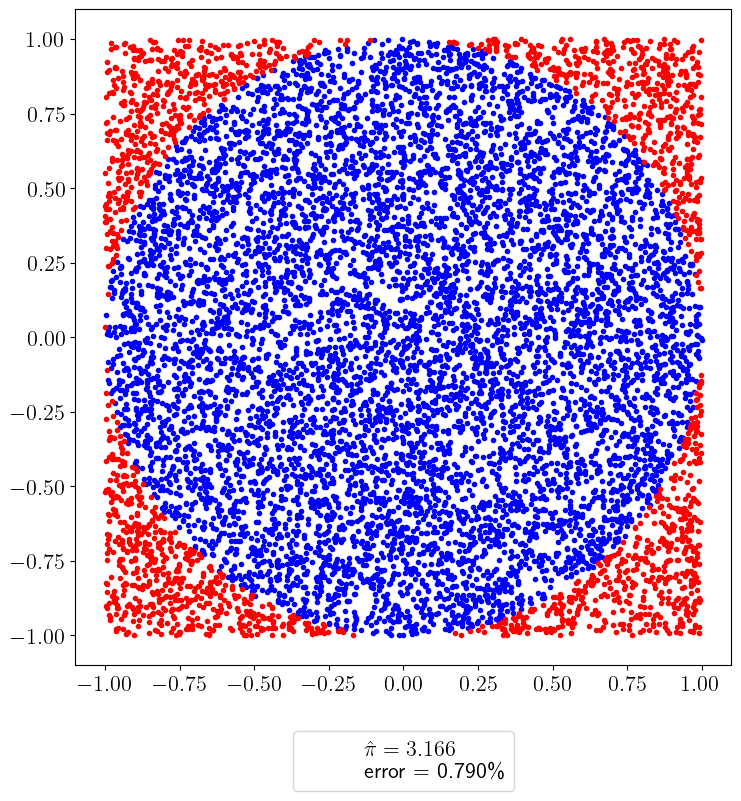

In [34]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 16
plt.rcParams['text.usetex'] = True

N = 10000
x, y = np.random.uniform(-1, 1, size=(2, N))
inside = (x**2 + y**2) <= 1  # bool数列，array([ True,  True,  True, ...,  True,  True,  True])
mpi = inside.sum() * 4 / N
error = abs((mpi - np.pi) / np.pi) * 100
outside = np.invert(inside)  # 二进制数取反，array([False, False, False, ..., False, False, False])

plt.figure(figsize=(8, 8))
plt.plot(x[inside], y[inside], 'b.')
plt.plot(x[outside], y[outside], 'r.')
label_text = fr'$\hat{{\pi}} = {mpi:4.3f}$' + '\n' + fr'error = {error:4.3f}\%'
plt.plot(0, 0, label=label_text, alpha=0)
plt.axis('square')

# 将图例放在正下方，居中显示
legend = plt.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', 
                   borderaxespad=0., ncol=1, frameon=True)

# 调整布局确保图例显示完整
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # 根据需要调整这个值
plt.show()

例 16.7 炮弹射击的目标为一椭圆 $\frac{x^2}{120^2} + \frac{y^2}{80^2} = 1$ 所围成的区域的中心, 当瞄准目标的中心发射时, 受到各种因素的影响, 炮弹着地点与目标中心有随机偏差. 设炮弹着地点围绕目标中心呈二维正态分布, 且偏差的标准差在 $x$ 和 $y$ 方向均为 $100\mathrm{m}$, 并相互独立, 用 Monte Carlo 方法计算炮弹落在椭圆区域内的概率, 并与数值积分计算的概率进行比较.

解 炮弹的落点为二维随机变量, 记为 $(X, Y)$, $(X, Y)$ 的联合概率密度函数为
$$
f(x, y) = \frac{1}{20000\pi} e^{-\frac{x^2 + y^2}{20000}}.
$$
炮弹落在椭圆区域内的概率为
$$
p = \iint\limits_{\frac{x^2}{120^2} + \frac{y^2}{80^2} \leq 1} \frac{1}{20000\pi} e^{-\frac{x^2 + y^2}{20000}} dxdy.
$$

利用 Python 数值解的命令, 求得 $p = 0.3754$; 也可以使用 Monte Carlo 方法求概率. 模拟发射了 $N$ 发炮弹, 统计炮弹落在椭圆 $\frac{x^2}{120^2} + \frac{y^2}{80^2} = 1$ 内部的次数 $n$, 用炮弹落在椭圆内的频率近似所求的概率, 模拟结果为所求的概率在 $0.3754$ 附近波动.

```np.random.multivariate_normal(mean, cov, size, …)```
参数：  
- mean：1-D array-like，长度 d；  
- cov：2-D array-like，形状 (d,d)；  
- size：int 或 tuple，输出样本形状。  
返回值：ndarray，形状 (N, 2)，float64。  

In [ ]:
import numpy as np
from scipy.integrate import dblquad

fxy = lambda x, y: 1 * np.exp(-(x**2 + y**2) / 20000) / (20000 * np.pi)  # 被积函数
bdy = lambda x: 80 * np.sqrt(1 - x**2 / 120**2)  # 积分y时的积分上下限
p1 = dblquad(fxy, -120, 120, lambda x: -bdy(x), bdy)  # 求二重积分,先y后x
print(f"概率的数值解为: {p1}")

N = 10000000
mu = [0, 0]
cov = 10000 * np.identity(2)  # np.identity(2)返回二阶单位矩阵
a = np.random.multivariate_normal(mu, cov, size=N)  # (10000000, 2)作用：从 N(μ, Σ) 生成 N 个二维样本
n = ((a[:, 0]**2 / 120**2 + a[:, 1]**2 / 80**2) <= 1).sum()  # a[:, 0]代表x，a[:, 1]代表y，落在椭圆内的点的数量
p2 = n / N
print(f"概率的近似值为: {p2}")

概率的数值解为: (0.37537924340945633, 5.798393432066007e-10)
概率的近似值为: 0.3756831


### 3. **求全局最优解**

例 16.8 求下列函数的最大值:

$$
f(x) = (1 - x^3)\sin(3x),\quad -2\pi \leqslant x \leqslant 2\pi.
$$

解 为了便于理解, 先作图 16.3, 可见, 函数在 $-6$ 和 $6$ 附近达到最大值, 最大值接近 $195$. 如果使用优化命令 `fminbound` 求解, 只能求得局部极大点 $x = -3.7505$, 对应的局部极大值为 $y = 52.0046$. 显然结果是错误的, 原因是 `fminbound` 容易陷入局部极值, 这也是**许多优化算法难以克服的一个困难**.

用随机模拟的方法, 就是随机产生若干个自变量的值来搜索, 例如, 取 $100$ 个点, 求得的最大值在 $194$ 附近, 结果要好得多.

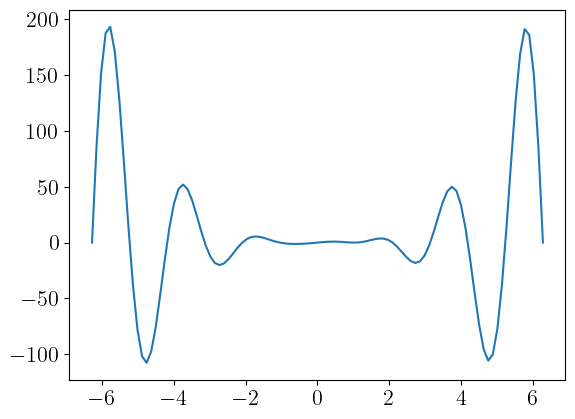

-3.7505026680508093
52.00462222535155
-----------------------
Optimization terminated successfully.
         Current function value: -194.906195
         Iterations: 15
         Function evaluations: 30
[-5.81608816]
[194.90619465]
-----------------------
[-5.83437818]
194.59870037910923


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fminbound, fmin

plt.rcParams['font.size'] = 16
fx = lambda x: (1 - x**3) * np.sin(3 * x)
x0 = np.linspace(-2 * np.pi, 2 * np.pi, 100)
y0 = fx(x0)
plt.plot(x0, y0)
plt.show()

# 局部最大
xm1 = fminbound(lambda x: -fx(x), -2 * np.pi, 2 * np.pi)  # 注意fx前面的符号，求最大
ym1 = fx(xm1)
print(xm1)
print(ym1)
print('-----------------------')

# 全局最大
xm2 = fmin(lambda x: -fx(x), -2 * np.pi)
ym2 = fx(xm2)
print(xm2)
print(ym2)
print('-----------------------')

# Monte Carlo求全局最大
x = np.random.uniform(-2 * np.pi, 2 * np.pi, 100)
y = fx(x)
ym = y.max()
xm = x[y == ym]
print(xm)
print(ym)

### 4. **库存管理问题（报童模型（Newsvendor Model））**

例 16.9 某小贩每天以 $a = 2$ 元/束的价格购进一种鲜花，卖价为 $b = 3$ 元/束，当天卖不出去的花全部损失。顾客一天内对花的需求量 $X$ 是随机变量，$X$ 服从泊松分布
$$
P\{X = k\} = e^{-\lambda} \frac{\lambda^k}{k!}, \quad k = 0, 1, 2, \cdots,
$$
其中参数 $\lambda = 10$。问小贩每天应购进多少束鲜花才能得到好收益？

**解** 这是一个随机决策问题，要确定每天应购进的鲜花数量以使收入最高。

设小贩每天购进 $u$ 束鲜花。如果这天需求量 $X \leqslant u$，则其收入为 $bX - au$；如果需求量 $X > u$，则其收入为 $bu - au$，因此小贩一天的期望收入为
$$
J(u) = -au + \sum_{k = 0}^{u} bk \cdot e^{-\lambda} \frac{\lambda^k}{k!} + \sum_{k = u + 1}^{\infty} bu \cdot e^{-\lambda} \frac{\lambda^k}{k!}.
$$
问题归结为在 $a, b, \lambda$ 已知时，求 $u$ 使得 $J(u)$ 最大。因而最佳购进量 $u^*$ 满足
$$
J(u^*) \geqslant J(u^* + 1)
$$
$$
J(u^*) \geqslant J(u^* - 1)
$$

由于
$$
J(u + 1) - J(u) = -a + be^{-\lambda} \sum_{k = u + 1}^{\infty} \frac{\lambda^k}{k!} = -a + b\left(1 - \sum_{k = 0}^{u} e^{-\lambda} \frac{\lambda^k}{k!}\right),
$$
最佳购进量 $u^*$ 满足
$$
1 - \sum_{k = 0}^{u^*} e^{-\lambda} \frac{\lambda^k}{k!} \leqslant \frac{a}{b},(J(u^*) \geqslant J(u^* + 1))
$$ 
$$
1 - \sum_{k = 0}^{u^* - 1} e^{-\lambda} \frac{\lambda^k}{k!} \geqslant \frac{a}{b}.(J(u^*) \geqslant J(u^* - 1))
$$

记泊松分布的分布函数为 $F(i) = P\{X \leqslant i\} = \sum\limits_{k = 0}^{i} e^{-\lambda} \frac{\lambda^k}{k!}$，则最佳购进量 $u^*$ 满足
$$
F(u^* - 1) \leqslant 1 - \frac{a}{b} \leqslant F(u^*).
$$

查泊松分布表，或利用 Python 软件，求得最佳购进量 $u^* = 9$。


In [ ]:
from scipy.stats import poisson

a = 2
b = 3
lamda = 10  # 泊松分布的参数lambda，关键字写成lamda
p = 1 - a / b
u = poisson.ppf(1 - a / b, lamda)  # ppf--percent point function通过概率求变量（订购量）满足概率大于1 - a/b,求最佳订购量
p1 = poisson.cdf(u - 1, lamda)  # p1和p2为验证最佳购进量
p2 = poisson.cdf(u, lamda)  # cdf--cumulative distribution function
print(u, p1, p, p2)

9.0 0.3328196787507191 0.33333333333333337 0.4579297144718523


下面用计算机模拟进行检验.

对不同的 $a,b,\lambda$, 用计算机模拟求最优决策 $u$ 的算法如下.  

步骤 1: 给定 $a,b,\lambda$, 记进货量为 $u$ 时, 收益为 $M_u$, 当 $u = 0$ 时, $M_0 = 0$; 令 $u = 1$, 继续下一步.  

步骤 2: 对随机需求变量 $X$ 做模拟, 求出收入, 共做 $n$ 次模拟, 求出收入的平均值 $M_u$.  

步骤 3: 若 $M_u \geqslant M_{u - 1}$, 令 $u = u + 1$, 转步骤 2; 若 $M_u < M_{u - 1}$, 输出 $u^* = u - 1$, 停止.  

用 Python 软件进行模拟, 求得最佳进货量为 $9$, 发现其与理论推导符合得很好. 

模拟的 Python 程序如下:  

In [ ]:
# Monte Carlo模拟生成随机抽样
import numpy as np

a = 2
b = 3
lamda = 10
M1 = 0
u = 1
n = 10000
for i in range(1, 2 * lamda):
    d = np.random.poisson(lamda, n)  # 产生n个服从泊松分布的需求数据
    # (u <= d)供不应求，(u > d)供大于求，a*(u - d)卖不出去，净亏损，可以用选择来写
    M2 = np.mean(((b - a) * u * (u <= d) + ((b - a)*d - a*(u - d)) * (u > d)))  # 求平均利润
    if M2 > M1:
        M1 = M2
        u += 1
    else:
        print(f"最佳购进量: {u-1}")
        break

最佳购进量: 9


### 5. **排队问题**

例 16.10 某修理店只有一个修理工, 来修理的顾客到达时间间隔服从负指数分布, 平均间隔时间 $10\mathrm{min}$; 对顾客的服务时间 (单位: $\mathrm{min}$) 服从 $[4,15]$ 上的均匀分布; 当到来的顾客较多时, 一部分顾客便需排队等待, 排队按先到先服务规则, 队长无限制; 服务完的顾客便离开修理店. 假定一个工作日为 $8\mathrm{h}$.  

(1) 模拟一个工作日内完成服务的个数及顾客平均等待时间.  

(2) 模拟 $1000$ 个工作日, 求出平均每日完成服务的个数及每日顾客的平均等待时间.  

解 记第 $k$ 位顾客的到达时间间隔 $t_k$, 到达时刻 $c_k$, 离开时刻 $g_k$, 等待时间 $w_k$, 它们很容易根据已有的到达间隔 $t_k$ 和服务时间 $s_k$ 按照以下的递推关系得到  
$$
c_k = c_{k - 1} + t_k, \quad g_k = \max(c_k, g_{k - 1}) + s_k, \quad w_k = \max(0, g_{k - 1} - c_k), \quad k = 2, 3, \cdots.
$$

模拟一个工作日完成服务的个数及顾客平均等待时间, 运行结果特别不稳定.  

模拟 $1000$ 个工作日, 平均每日完成服务的个数约为 $44$, 平均等待时间在 $25\mathrm{min}$ 左右.  

In [ ]:
import numpy as np

np.random.seed(4)  # 进行一致性比较，每次运行结果一样

# t-->c-->g-->w(所求)
def oneday():
    W = [0]  # 第一个顾客的等待时间
    t0 = np.random.exponential(10)  # exponential指数分布，平均间隔时间为10(beta=                                                   1/lambda),密度函数lambda*exp(-lambda*x),分布函数1-exp(-lambda*x)
    c0 = t0
    g0 = c0 + np.random.uniform(4, 15)
    g = g0
    while g < 480:
        t = np.random.exponential(10)  # 下一个到达时间间隔
        c = c0 + t
        w = max(0, g - c)  # 下一个等待时间
        g = max(g, c) + np.random.uniform(4, 15)  # 下一个离开时刻,服务时间服从均匀分布U(4, 15)
        c0 = c  # 把当前到达时刻保存起来
        W.append(w)  # 把等待时间保存到列表
    return len(W), np.mean(W)

W1 = oneday()
print(f"服务人数和平均等待时间为: {W1}")

d = 1000  # 模拟1000天
T = np.zeros(d)
N = np.zeros(d)
for i in range(d):
    N[i], T[i] = oneday()
print(f"平均服务人数为: {np.round(N.mean())}")
print(f"平均等待时间为: {T.mean()}")

服务人数和平均等待时间为: (39, 27.715473775462396)
平均服务人数为: 44.0
平均等待时间为: 25.66246800140869


### 6. 零件参数设计

例 16.11 (零件参数设计) 一件产品由若干零件组装而成, 标志产品性能的某个参数取决于这些零件的参数. 零件参数包括标定值和容差两部分. 进行成批生产时, 标定值表示一批零件该参数的平均值, 容差则给出了参数偏离其标定值的容许范围. 若将零件参数视为随机变量, 则标定值代表期望值, 在生产部门无特殊要求时, 容差通常规定为均方差的 3 倍.  

进行零件参数设计, 就是要确定其标定值和容差. 这时要考虑两方面因素:  

(1) 当各零件组装成产品时, 如果产品参数偏离预先设定的目标值, 就会造成质量损失, 偏离越大, 损失越大;  

(2) 零件容差的大小决定了其制造成本, 容差设计得越小, 成本越高.  

粒子分离器某参数 (记作 $y$) 由 7 个零件的参数 (记作 $x_1, x_2, \cdots, x_7$) 决定, 经验公式为  
$$
y = 174.42 \left( \frac{x_1}{x_5} \right) \left( \frac{x_3}{x_2 - x_1} \right)^{0.85} \sqrt{ \frac{1 - 2.62 \left[ 1 - 0.36 \left( \frac{x_4}{x_2} \right)^{-0.56} \right]^{3/2} \left( \frac{x_4}{x_2} \right)^{1.16} }{x_6 x_7} }.
$$  

$y$ 的目标值 (记作 $y_0$) 为 1.50. 当 $y$ 偏离 $y_0 \pm 0.1$ 时, 产品为次品, 质量损失为 1000 元; 当 $y$ 偏离 $y_0 \pm 0.3$ 时, 产品为废品, 损失为 9000 元.  

零件参数的标定值有一定的容许变化范围; 容差分为 A, B, C 三个等级, 用标定值的相对值表示, A 等为 $\pm 1\%$, B 等为 $\pm 5\%$, C 等为 $\pm 10\%$. 7 个零件参数标定值及容差如表 16.3 所示. 求每件产品的平均损失.  

表 16.3 7 个零件参数数据  

|  | $x_1$ | $x_2$ | $x_3$ | $x_4$ | $x_5$ | $x_6$ | $x_7$ |
| ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- |
| 标定值 | 0.1 | 0.3 | 0.1 | 0.1 | 1.5 | 16 | 0.75 |
| 容差 | B | B | B | C | C | B | B |  


解 在这个问题中, 主要的困难是产品的参数值 $y$ 是一个随机变量, 由于 $y$ 与各零件参数间是一个复杂的函数关系, 无法解析地得到 $y$ 的概率分布. 采用随机模拟的方法计算, 这一方法的思路其实很简单, 用计算机模拟工厂生产大量 “产品”(如 100000 件), 计算产品的总损失, 从而得到每件产品的平均损失. 可以假设 7 个零件参数服从正态分布. 根据表 16.3 数据及标定值和容差的定义, $x_1 \sim N(0.1, (0.005/3)^2)$, $x_2 \sim N(0.3, 0.005^2)$, $x_3 \sim N(0.1, (0.005/3)^2)$, $x_4 \sim N(0.1, (0.01/3)^2)$, $x_5 \sim N(1.5, 0.05^2)$, $x_6 \sim N(16, (0.8/3)^2)$, $x_7 \sim N(0.75, 0.0125^2)$. 下面的 Python 程序产生 100000 对零件参数随机数, 通过随机模拟法求得每件产品的平均损失约为 2500 元.  


In [ ]:
import numpy as np

N = 100000
mu = [0.1, 0.3, 0.1, 0.1, 1.5, 16, 0.75]
cov = np.diag([(0.005/3)**2, 0.005**2, (0.005/3)**2, (0.01/3)**2, 0.05**2, (0.8/3)**2, 0.0125**2])  # 方差(标定值*容差/3)**2，对角矩阵,(7, 7)
a = np.random.multivariate_normal(mu, cov, size=N)  # 从 N(μ, Σ) 生成 N 个二维样本，(N, 7)
x1, x2, x3, x4, x5, x6, x7 = a.T
y = 174.42 * x1/x5 * (x3 / (x2-x1))**0.85 * np.sqrt((1 - 2.62*(1 - 0.36*(x4/x2)**(-0.56))**(3/2) * (x4/x2)**1.16) / (x6*x7))
d = np.abs(y - 1.5)  # 误差
f = np.sum(9000 * (d >= 0.3) + 1000 * ((d < 0.3) & (d >=0.1))) / N  # 损失多少钱
print(f"平均损失为: {f}元")

平均损失为: 2506.73元
